In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
df=pd.read_csv('Fish.csv')
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [132]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [133]:
df.duplicated().sum()

np.int64(0)

In [136]:
df.drop("Species",axis=1)

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,12.2,11.5,12.2,13.4,2.0904,1.3936
155,13.4,11.7,12.4,13.5,2.4300,1.2690
156,12.2,12.1,13.0,13.8,2.2770,1.2558
157,19.7,13.2,14.3,15.2,2.8728,2.0672


In [74]:
x=df[['Length1']]
y=df[['Weight']]
x.shape
y.shape

(159, 1)

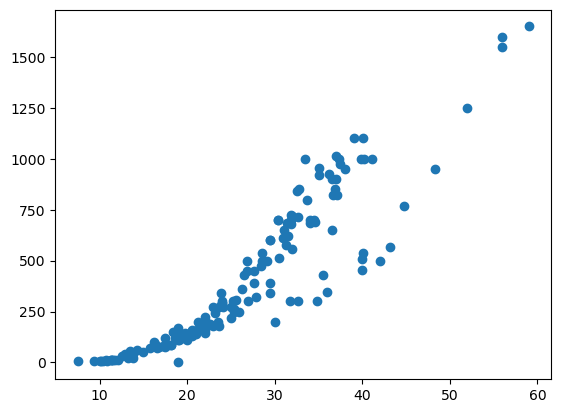

In [75]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [78]:
x_train

,Length1
124,39.8
49,22.0
68,19.8
2,23.9
59,33.7
...,...
113,34.0
64,17.5
15,29.4
125,40.1


In [79]:
x_test

,Length1
35,12.9
85,19.3
47,21.1
24,31.9
129,31.7
95,21.5
128,30.0
10,28.4
58,28.5
104,25.4


In [80]:
x_train.shape,x_test.shape,y_test.shape,y_train.shape

((127, 1), (32, 1), (32, 1), (127, 1))

In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
model=LinearRegression()

In [83]:
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
y_pred=model.predict(x_test)
y_pred

array([[ -35.804181  ],
       [ 177.06733726],
       [ 236.93745177],
       [ 596.15813884],
       [ 589.50590389],
       [ 250.24192167],
       [ 532.96190686],
       [ 479.74402729],
       [ 483.07014476],
       [ 379.96050311],
       [ 240.26356925],
       [  77.28381308],
       [ 153.78451495],
       [ 576.201434  ],
       [ 140.48004506],
       [ -89.02206056],
       [ 366.65603321],
       [ 333.39485849],
       [ 167.08898484],
       [ 300.13368376],
       [ 566.22308158],
       [ 266.87250903],
       [ -25.82582858],
       [ 373.30826816],
       [ 579.52755148],
       [ 213.65462946],
       [ 167.08898484],
       [ 336.72097596],
       [ 865.57365414],
       [-128.93547024],
       [ 200.35015957],
       [ 300.13368376]])

In [101]:
m=model.coef_

In [102]:
b=model.intercept_

In [87]:
pd.DataFrame(
    {
        'actual_data':y_test.squeeze(),
        'predicted_data':y_pred.squeeze()
    }
)

,actual_data,predicted_data
35,40.0,-35.804181
85,130.0,177.067337
47,160.0,236.937452
24,700.0,596.158139
129,300.0,589.505904
95,170.0,250.241922
128,200.0,532.961907
10,475.0,479.744027
58,540.0,483.070145
104,265.0,379.960503


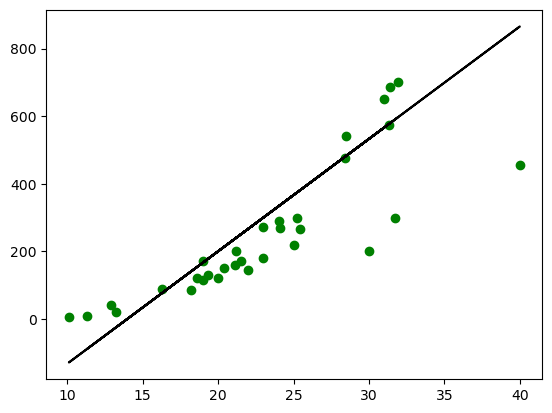

In [98]:
plt.scatter(x_test,y_test,label='Actual Data',color='green')
plt.plot(x_test,y_pred,label='Predicted Data',color='black')

In [94]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [95]:
mean_squared_error(y_test,y_pred)

16917.312221946187

In [96]:
mean_absolute_error(y_test,y_pred)

93.87412129033645

In [97]:
r2_score(y_test,y_pred)

0.558839021555892

In [99]:
x_test=[[25]]

In [105]:
y_new_pred=m*x_test+b

In [106]:
y_new_pred

array([[366.65603321]])

In [127]:
test_size=[0.1,0.2,0.3,0.4,0.5]
mse_array=[]
r2_array=[]
for i in test_size:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=10)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    
    mse=mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)

    mse_array.append(mse)
    r2_array.append(r2)
    
    print(i," ",mse)
    print(i," ",r2)
    print("------------")
print(mse_array)
print(f"Test size: {test_size[mse_array.index(min(mse_array))]}, Min MSE : {min(mse_array)} ")    
print(f"Test size: {test_size[r2_array.index(max(r2_array))]}, Max MSE : {max(r2_array)} ")    




0.1   15523.565250616111
0.1   0.617883675271323
------------
0.2   16917.312221946187
0.2   0.558839021555892
------------
0.3   21829.068497661665
0.3   0.7065203708440448
------------
0.4   21568.924440960644
0.4   0.7087432274790084
------------
0.5   20564.277656171947
0.5   0.7474337483186893
------------
[15523.565250616111, 16917.312221946187, 21829.068497661665, 21568.924440960644, 20564.277656171947]
Test size: 0.1, Min MSE : 15523.565250616111 
Test size: 0.5, Max MSE : 0.7474337483186893 


Text(0, 0.5, 'R2 score')

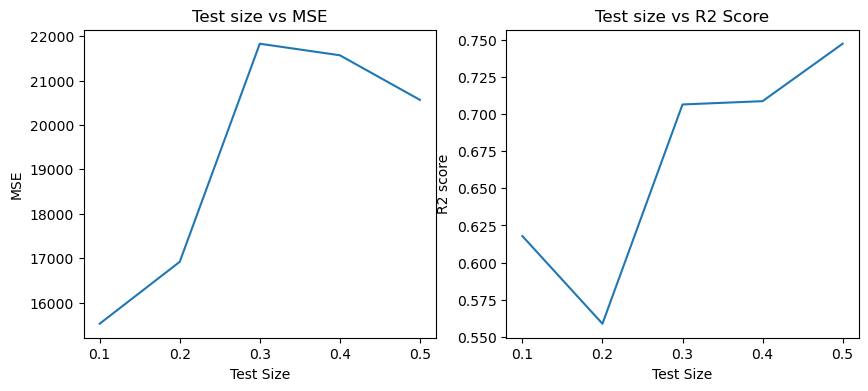

In [130]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Test size vs MSE")
plt.plot(test_size,mse_array)
plt.xlabel("Test Size")
plt.ylabel("MSE")

plt.subplot(1,2,2)
plt.title("Test size vs R2 Score")
plt.plot(test_size,r2_array)
plt.xlabel("Test Size")
plt.ylabel("R2 score")

In [143]:
df=df.drop("Species",axis=1)


In [144]:
df.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


<Axes: >

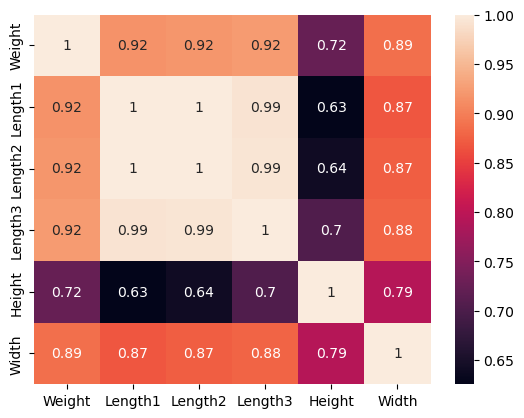

In [147]:
sns.heatmap(df.corr(),annot=True)


In [148]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

In [149]:
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [150]:
y_pred=model.predict(x_test)
y_pred

array([[-121.82353189],
       [ 377.44941358],
       [ 280.81594026],
       [ 197.06693006],
       [ 841.2900855 ],
       [ 776.86776995],
       [ 197.06693006],
       [1356.66860985],
       [ 313.02709804],
       [ 419.32391868],
       [ 261.4892456 ],
       [ 490.18846578],
       [ -31.63229013],
       [ 744.65661218],
       [ 232.49920361],
       [ -44.51675323],
       [ 261.4892456 ],
       [ 609.36974954],
       [ 564.27412866],
       [ 847.73231705],
       [ 747.87772796],
       [ 503.07292889],
       [ -70.28567945],
       [ 126.20238296],
       [ 744.65661218],
       [ 573.93747599],
       [ 313.02709804],
       [ 213.17250894],
       [ 190.6246985 ],
       [ 535.28408666],
       [  58.55895164],
       [ 561.05301288]])

In [ ]:
Length1 :12.5
Length2 :23.6
Length3 :15.7
Height  :11.7
Width   :5.8